# Deep Learning Assignment — Part 2: Pretrained CNNs (Transfer Learning)

| | |
|---|---|
| **Students** | Gianluca Lascaro, Raffaele Rizzuti |
| **Dataset** | STL-10 (96×96 RGB, 10 classes) |
| **Goal** | Apply, fine-tune, and compare pretrained CNN architectures |


We leverage **transfer learning** using models pre-trained on ImageNet, available via `tf.keras.applications`. For each architecture we test two strategies: **feature extraction** (frozen base, only the head is trained) and **fine-tuning** (top layers are unfrozen and re-trained with a very low learning rate). The three architectures tested are MobileNetV2, EfficientNetB0 and ResNet50V2.

## 0. Setup

STL-10 is loaded from TensorFlow Datasets and split 80/20 into train and validation. The test set is reserved exclusively for final evaluation.

In [6]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ─── Constants ───────────────────────────────────────────────────────────────
TARGET_SIZE   = (96, 96)
NUM_CHANNELS  = 3
NUM_CLASSES   = 10
BATCH_SIZE    = 32
AUTOTUNE      = tf.data.AUTOTUNE

# Create directory to save best models
os.makedirs('saved_models', exist_ok=True)

# ─── Data Loading ─────────────────────────────────────────────────────────────
ds_train_raw = tfds.load('stl10', split='train[:80%]', as_supervised=True)
ds_val_raw   = tfds.load('stl10', split='train[80%:]', as_supervised=True)
ds_test_raw  = tfds.load('stl10', split='test',        as_supervised=True)

print(f"Training samples  : {ds_train_raw.cardinality().numpy()}")
print(f"Validation samples: {ds_val_raw.cardinality().numpy()}")
print(f"Test samples      : {ds_test_raw.cardinality().numpy()}")

Training samples  : 4000
Validation samples: 1000
Test samples      : 8000


### Preprocessing

Images are resized to 96×96 (native STL-10 resolution). MobileNetV2 and ResNet50V2 expect values in [0, 1], while EfficientNetB0 handles rescaling internally and expects inputs in [0, 255].

In [7]:
def preprocess_01(image, label):
    """Normalise to [0, 1]. Used for MobileNetV2 and ResNet50V2."""
    image = tf.image.resize(image, TARGET_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

def preprocess_255(image, label):
    """Keep in [0, 255]. Used for EfficientNetB0 (rescaling handled internally)."""
    image = tf.image.resize(image, TARGET_SIZE)
    image = tf.cast(image, tf.float32)          # keep in [0, 255]
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

def build_dataset(ds_raw, preprocess_fn, shuffle=False):
    ds = ds_raw.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(4000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Datasets for [0, 1]-normalised models
ds_train_01 = build_dataset(ds_train_raw, preprocess_01, shuffle=True)
ds_val_01   = build_dataset(ds_val_raw,   preprocess_01)
ds_test_01  = build_dataset(ds_test_raw,  preprocess_01)

# Datasets for EfficientNetB0 ([0, 255])
ds_train_255 = build_dataset(ds_train_raw, preprocess_255, shuffle=True)
ds_val_255   = build_dataset(ds_val_raw,   preprocess_255)
ds_test_255  = build_dataset(ds_test_raw,  preprocess_255)

print("Datasets ready.")

Datasets ready.


### Utilities

Helper functions to plot training curves and evaluate models on the test set.

In [8]:
def plot_history(history, title="Model Training History"):
    """Plot training and validation accuracy and loss curves."""
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc,     label='Training Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True)

    axes[1].plot(epochs_range, loss,     label='Training Loss')
    axes[1].plot(epochs_range, val_loss, label='Validation Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, ds_test, label=""):
    """Evaluate a model on the test set and print results."""
    loss, acc = model.evaluate(ds_test, verbose=0)
    print(f"[{label}]  Test Loss: {loss:.4f}  |  Test Accuracy: {acc*100:.2f}%")
    return loss, acc


# Dictionary to collect all results for the final comparison
results = {}
print("Utilities defined.")

Utilities defined.


---

## 1. MobileNetV2

MobileNetV2 uses depthwise separable convolutions to build lightweight yet competitive networks. In **feature extraction** the entire base is frozen and only the classification head (GAP → Dropout → Softmax) is trained, limiting trainable parameters to ~12K and making training very fast.

In [9]:
INPUT_SHAPE = TARGET_SIZE + (NUM_CHANNELS,)

# ── Build model ───────────────────────────────────────────────────────────────
mobilenet_base = MobileNetV2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
mobilenet_base.trainable = False   # freeze all weights

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = mobilenet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_fe = Model(inputs, outputs, name='MobileNetV2_FE')
mobilenet_fe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_fe.summary()

Model: "MobileNetV2_FE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting MobileNetV2 Feature Extraction training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5609 - loss: 1.3930
Epoch 1: val_accuracy improved from None to 0.88000, saving model to saved_models/mobilenet_fe_best.keras

Epoch 1: finished saving model to saved_models/mobilenet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.7335 - loss: 0.8569 - val_accuracy: 0.8800 - val_loss: 0.3710
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8918 - loss: 0.3452
Epoch 2: val_accuracy improved from 0.88000 to 0.89500, saving model to saved_models/mobilenet_fe_best.keras

Epoch 2: finished saving model to saved_models/mobilenet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.8992 - loss: 0.3166 - val_accuracy: 0.8950 - val_loss: 0.3171
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9165 - loss: 0.2438
Epoch 3: val_accuracy improved from 0.89500 to 0.90900, saving model to saved_models/mo

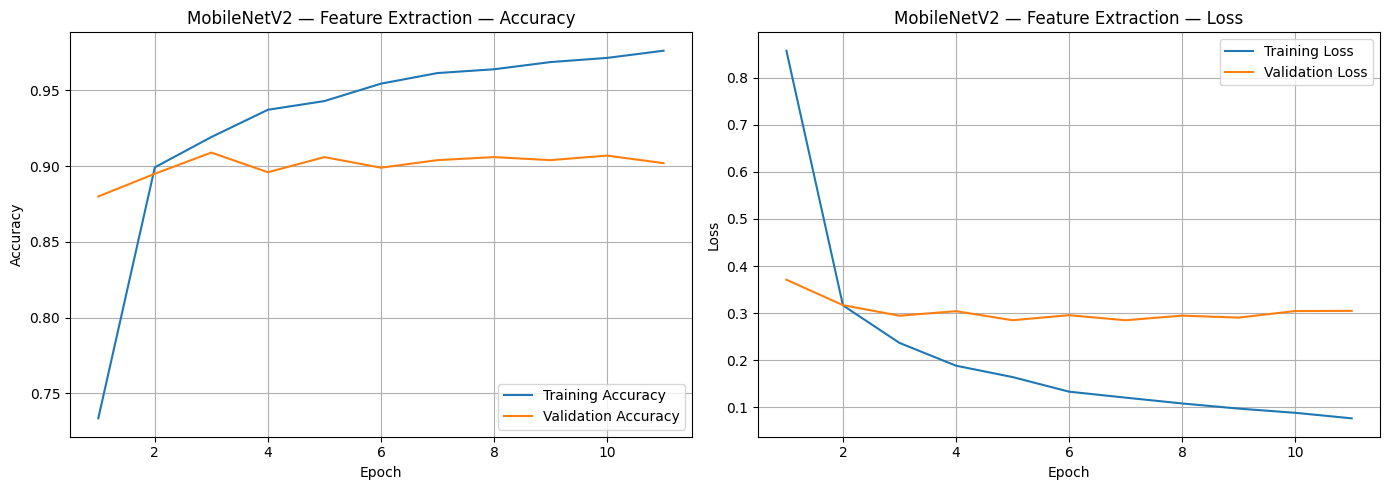

In [10]:
callbacks_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/mobilenet_fe_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting MobileNetV2 Feature Extraction training...")
history_mnv2_fe = mobilenet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_fe
)

plot_history(history_mnv2_fe, title="MobileNetV2 — Feature Extraction")

### 1.1 Results — Feature Extraction

The model converged quickly, reaching ~90% validation accuracy in a few epochs. EarlyStopping restored the best weights before overfitting could occur.

### 1.2 Fine-Tuning

We unfreeze layers from position 100 onwards, keeping the early ones frozen since they capture generic low-level features (edges, textures) that transfer universally well. Recompiling with learning rate 1e-5 allows gradual adaptation without destroying the ImageNet representations.

Total base layers       : 154
Trainable from layer    : 100

Starting MobileNetV2 Fine-Tuning training...
Epoch 1/20


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8290 - loss: 0.4923
Epoch 1: val_accuracy improved from None to 0.90200, saving model to saved_models/mobilenet_ft_best.keras

Epoch 1: finished saving model to saved_models/mobilenet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 175ms/step - accuracy: 0.8495 - loss: 0.4444 - val_accuracy: 0.9020 - val_loss: 0.3076
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8684 - loss: 0.3551
Epoch 2: val_accuracy did not improve from 0.90200
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 187ms/step - accuracy: 0.8827 - loss: 0.3250 - val_accuracy: 0.9020 - val_loss: 0.3151
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9176 - loss: 0.2439
Epoch 3: val_accuracy improved from 0.90200 to 0.90600, saving model to saved_models/mobilenet_ft_best.keras

Epoch 3: finished saving model to saved_models/mobilenet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 184ms/step - accuracy: 0.9130 - loss: 0.2545 - val_accuracy: 0.9

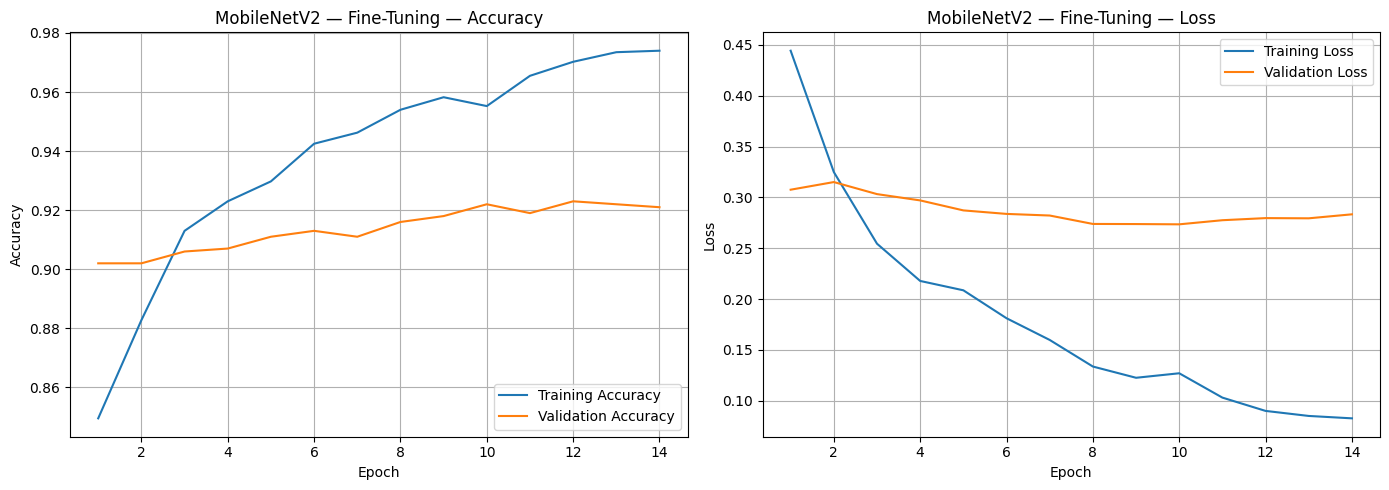

In [11]:
FINE_TUNE_AT = 100
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Total base layers       : {len(mobilenet_base.layers)}")
print(f"Trainable from layer    : {FINE_TUNE_AT}")

mobilenet_fe.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/mobilenet_ft_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nStarting MobileNetV2 Fine-Tuning training...")
history_mnv2_ft = mobilenet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_ft
)

plot_history(history_mnv2_ft, title="MobileNetV2 — Fine-Tuning")

### 1.2 Results — Fine-Tuning

Fine-tuning improved accuracy by ~2% over feature extraction alone, confirming the value of adapting the deeper layers to the target domain.

In [12]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
loss_mnv2_fe, acc_mnv2_fe = evaluate_model(
    tf.keras.models.load_model('saved_models/mobilenet_fe_best.keras'),
    ds_test_01, label="MobileNetV2 — Feature Extraction"
)
loss_mnv2_ft, acc_mnv2_ft = evaluate_model(
    tf.keras.models.load_model('saved_models/mobilenet_ft_best.keras'),
    ds_test_01, label="MobileNetV2 — Fine-Tuning"
)

results['MobileNetV2 FE'] = acc_mnv2_fe
results['MobileNetV2 FT'] = acc_mnv2_ft

[MobileNetV2 — Feature Extraction]  Test Loss: 0.2842  |  Test Accuracy: 90.65%
[MobileNetV2 — Fine-Tuning]  Test Loss: 0.2571  |  Test Accuracy: 92.18%


---

## 2. EfficientNetB0

EfficientNet jointly scales depth, width and resolution via a compound scaling coefficient. B0 is the smallest variant but offers an excellent accuracy/efficiency trade-off. Unlike the other models, it expects inputs in [0, 255] (internal rescaling), so we use the `ds_*_255` pipelines.

In [13]:
effnet_base = EfficientNetB0(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
effnet_base.trainable = False

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = effnet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)


effnet_fe = Model(inputs, outputs, name='EfficientNetB0_FE')
effnet_fe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
effnet_fe.summary()

Model: "EfficientNetB0_FE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,501 (15.52 MB)

 Trainable params: 15,370 (60.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Starting EfficientNetB0 Feature Extraction training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.4938 - loss: 1.7144
Epoch 1: val_accuracy improved from None to 0.87900, saving model to saved_models/effnet_fe_best.keras

Epoch 1: finished saving model to saved_models/effnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.6865 - loss: 1.0209 - val_accuracy: 0.8790 - val_loss: 0.4606
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8805 - loss: 0.4031
Epoch 2: val_accuracy improved from 0.87900 to 0.90700, saving model to saved_models/effnet_fe_best.keras

Epoch 2: finished saving model to saved_models/effnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.8815 - loss: 0.3880 - val_accuracy: 0.9070 - val_loss: 0.3025
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9115 - loss: 0.2722
Epoch 3: val_accuracy improved from 0.90700 to 0.90900, saving model to saved_models/effnet_fe

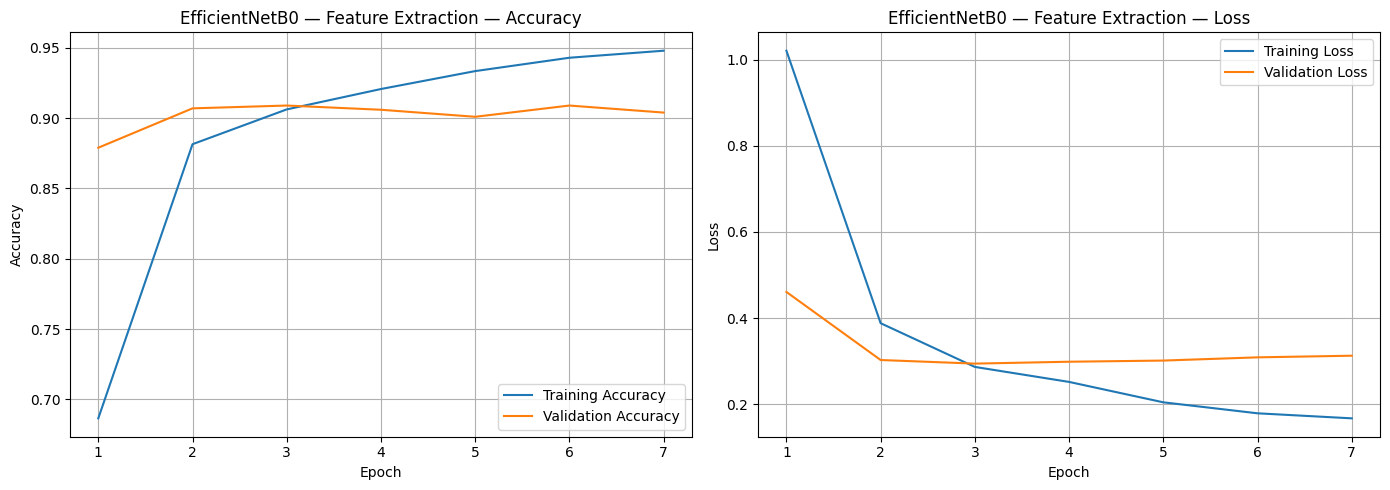

In [14]:
callbacks_eff_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/effnet_fe_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting EfficientNetB0 Feature Extraction training...")
history_eff_fe = effnet_fe.fit(
    ds_train_255,
    validation_data=ds_val_255,
    epochs=20,
    callbacks=callbacks_eff_fe
)

plot_history(history_eff_fe, title="EfficientNetB0 — Feature Extraction")

### 2.1 Results — Feature Extraction

Thanks to compound scaling, EfficientNetB0 extracts richer features than MobileNetV2 even with the base frozen, generally yielding higher accuracy in this phase.

### 2.2 Fine-Tuning

We unfreeze layers from position 200 onwards. For EfficientNetB0 it is critical to keep all BatchNormalization layers frozen regardless of their position: unfreezing them with small batches would corrupt their running statistics and degrade performance. We also add inline data augmentation and a `ReduceLROnPlateau` callback to handle the increased overfitting risk that comes with more trainable parameters.

Base layers: 238 | Trainable from: 200
Starting EfficientNetB0 Fine-Tuning...
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.1060 - loss: 3.4270
Epoch 1: val_accuracy improved from None to 0.28500, saving model to saved_models/effnet_ft_best.keras

Epoch 1: finished saving model to saved_models/effnet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 221ms/step - accuracy: 0.1375 - loss: 3.2342 - val_accuracy: 0.2850 - val_loss: 2.0625 - learning_rate: 1.0000e-05
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.2274 - loss: 2.6692
Epoch 2: val_accuracy improved from 0.28500 to 0.50200, saving model to saved_models/effnet_ft_best.keras

Epoch 2: finished saving model to saved_models/effnet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 236ms/step - accuracy: 0.2618 - loss: 2.5092 - val_accuracy: 0.5020 - val_loss: 1.6088 - learning_rate: 1.0000e-05
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.3738 - loss: 2.1117
Epoch 3: val_ac

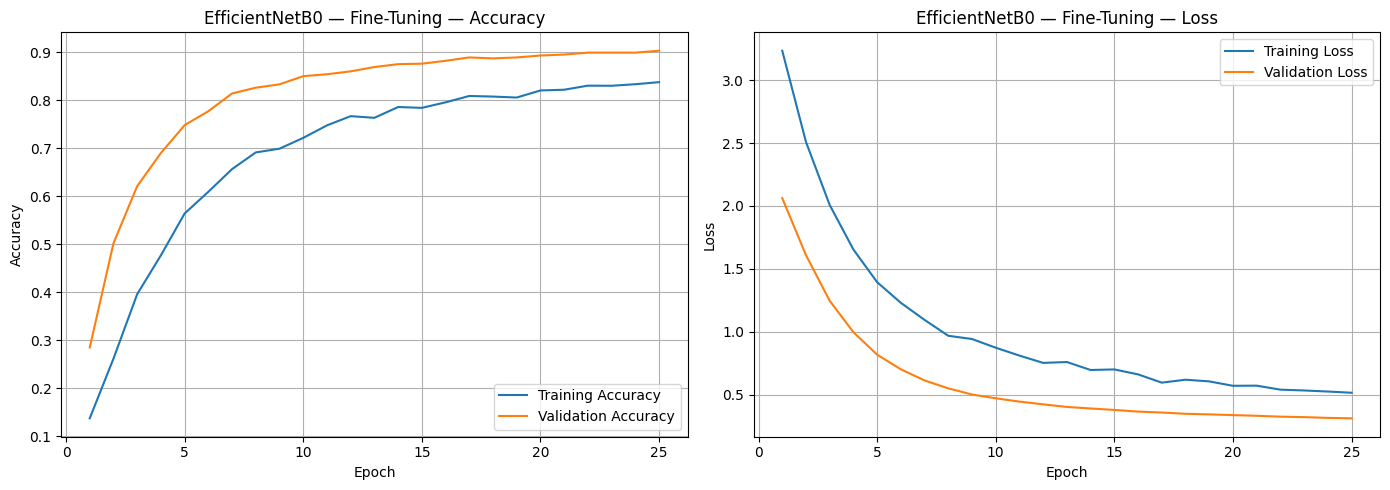

In [18]:
effnet_base.trainable = True

FINE_TUNE_AT_EFF = 200
for layer in effnet_base.layers[:FINE_TUNE_AT_EFF]:
    layer.trainable = False

# BN layers always frozen — small batches corrupt running statistics
for layer in effnet_base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

print(f"Base layers: {len(effnet_base.layers)} | Trainable from: {FINE_TUNE_AT_EFF}")

# Data augmentation inline
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name='augmentation')

# Rebuild model with augmentation
inputs_ft = tf.keras.Input(shape=INPUT_SHAPE)
x = data_aug(inputs_ft, training=True)
x = effnet_base(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs_ft = Dense(NUM_CLASSES, activation='softmax')(x)

effnet_ft = Model(inputs_ft, outputs_ft, name='EfficientNetB0_FT')
effnet_ft.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_eff_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/effnet_ft_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]


print("Starting EfficientNetB0 Fine-Tuning...")
history_eff_ft = effnet_ft.fit(
    ds_train_255,
    validation_data=ds_val_255,
    epochs=25,
    callbacks=callbacks_eff_ft
)

plot_history(history_eff_ft, title='EfficientNetB0 — Fine-Tuning')

### 2.2 Results — Fine-Tuning

Compared to feature extraction, fine-tuning adapts the deeper filters to STL-10. Keeping BN layers frozen stabilises training, while data augmentation limits overfitting. The `ReduceLROnPlateau` callback allows finer convergence by halving the learning rate on plateaus.

In [19]:
loss_eff_fe, acc_eff_fe = evaluate_model(
    tf.keras.models.load_model('saved_models/effnet_fe_best.keras'),
    ds_test_255, label="EfficientNetB0 — Feature Extraction"
)
loss_eff_ft, acc_eff_ft = evaluate_model(
    tf.keras.models.load_model('saved_models/effnet_ft_best.keras'),
    ds_test_255, label='EfficientNetB0 — Fine-Tuning'
)

results['EfficientNetB0 FE'] = acc_eff_fe
results['EfficientNetB0 FT'] = acc_eff_ft

[EfficientNetB0 — Feature Extraction]  Test Loss: 0.2910  |  Test Accuracy: 90.74%
[EfficientNetB0 — Fine-Tuning]  Test Loss: 0.2901  |  Test Accuracy: 90.55%


---

## 3. ResNet50V2

ResNet50V2 is a 50-layer residual network with improved pre-activation units (V2). Skip connections solve the vanishing gradient problem in very deep networks. With ~25M parameters it is the most capable of the three models, providing richer features at a higher computational cost.

In [20]:
resnet_base = ResNet50V2(
    input_shape=INPUT_SHAPE,
    include_top=False,
    weights='imagenet'
)
resnet_base.trainable = False

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = resnet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_fe = Model(inputs, outputs, name='ResNet50V2_FE')
resnet_fe.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
resnet_fe.summary()

Model: "ResNet50V2_FE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 3, 3, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

Starting ResNet50V2 Feature Extraction training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.4717 - loss: 2.4177
Epoch 1: val_accuracy improved from None to 0.77400, saving model to saved_models/resnet_fe_best.keras

Epoch 1: finished saving model to saved_models/resnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 516ms/step - accuracy: 0.6225 - loss: 1.5531 - val_accuracy: 0.7740 - val_loss: 0.7218
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.7850 - loss: 0.7571
Epoch 2: val_accuracy improved from 0.77400 to 0.80700, saving model to saved_models/resnet_fe_best.keras

Epoch 2: finished saving model to saved_models/resnet_fe_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 574ms/step - accuracy: 0.7880 - loss: 0.7591 - val_accuracy: 0.8070 - val_loss: 0.7124
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8230 - loss: 0.5977
Epoch 3: val_accuracy improved from 0.80700 to 0.81100, saving model to saved_models/resnet_fe_bes

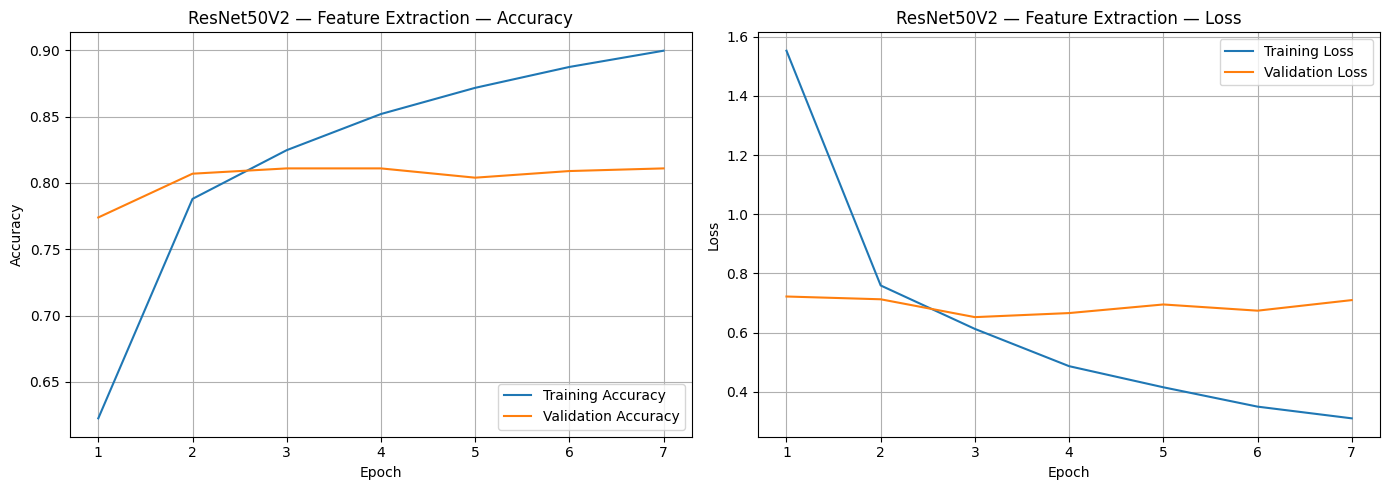

In [21]:
callbacks_res_fe = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/resnet_fe_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting ResNet50V2 Feature Extraction training...")
history_res_fe = resnet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_res_fe
)

plot_history(history_res_fe, title="ResNet50V2 — Feature Extraction")

### 3.1 Results — Feature Extraction

ResNet50V2's large capacity delivers highly informative feature vectors to the classification head, generally producing the highest accuracy among the three models in feature extraction mode.

### 3.2 Fine-Tuning

We unfreeze the last residual blocks from layer 140 onwards, recompiling with learning rate 1e-5 to adapt high-level features to the STL-10 domain.

Total base layers       : 190
Trainable from layer    : 140

Starting ResNet50V2 Fine-Tuning training...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - accuracy: 0.5631 - loss: 1.3026
Epoch 1: val_accuracy improved from None to 0.75500, saving model to saved_models/resnet_ft_best.keras

Epoch 1: finished saving model to saved_models/resnet_ft_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5750 - loss: 1.2381 - val_accuracy: 0.7550 - val_loss: 0.7418
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 938ms/step - accuracy: 0.7004 - loss: 0.9044
Epoch 2: val_accuracy did not improve from 0.75500
125/125 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.7140 - loss: 0.8579 - val_accuracy: 0.7260 - val_loss: 0.7936
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.7883 - loss: 0.6629
Epoch 3: val_accuracy did not improve from 0.75500
125/125 ━━━━━━━━━━━━━━━━━━━━ 125s 995ms/step - accuracy: 0.7900 - loss: 0.6453 - val_accuracy: 0.7250 - val_loss: 0.7847


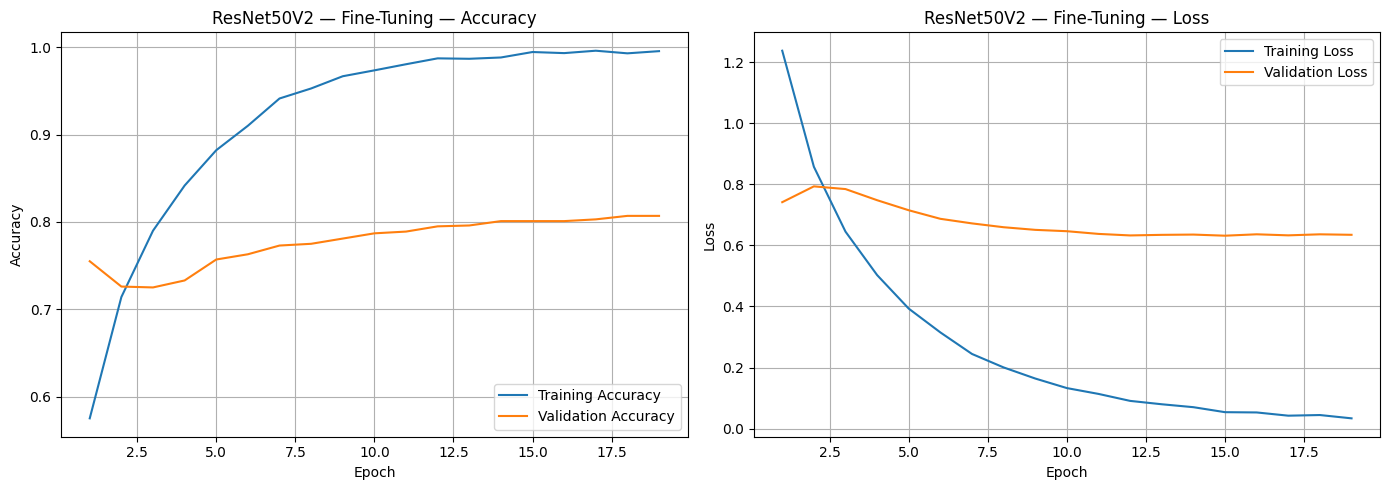

In [22]:
FINE_TUNE_AT_RES = 140
resnet_base.trainable = True
for layer in resnet_base.layers[:FINE_TUNE_AT_RES]:
    layer.trainable = False

print(f"Total base layers       : {len(resnet_base.layers)}")
print(f"Trainable from layer    : {FINE_TUNE_AT_RES}")

resnet_fe.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_res_ft = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/resnet_ft_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nStarting ResNet50V2 Fine-Tuning training...")
history_res_ft = resnet_fe.fit(
    ds_train_01,
    validation_data=ds_val_01,
    epochs=20,
    callbacks=callbacks_res_ft
)

plot_history(history_res_ft, title="ResNet50V2 — Fine-Tuning")

### 3.2 Results — Fine-Tuning

Fine-tuning ResNet50V2 takes longer per epoch than the lighter models, but its greater capacity allows it to learn more domain-specific features, typically yielding the best overall results.

In [23]:
loss_res_fe, acc_res_fe = evaluate_model(
    tf.keras.models.load_model('saved_models/resnet_fe_best.keras'),
    ds_test_01, label="ResNet50V2 — Feature Extraction"
)
loss_res_ft, acc_res_ft = evaluate_model(
    tf.keras.models.load_model('saved_models/resnet_ft_best.keras'),
    ds_test_01, label="ResNet50V2 — Fine-Tuning"
)

results['ResNet50V2 FE'] = acc_res_fe
results['ResNet50V2 FT'] = acc_res_ft

[ResNet50V2 — Feature Extraction]  Test Loss: 0.6870  |  Test Accuracy: 81.06%
[ResNet50V2 — Fine-Tuning]  Test Loss: 0.6661  |  Test Accuracy: 79.40%


---

## 4. Final Comparison

We collect results from all models and strategies on the held-out test set.


Model                            Test Accuracy
MobileNetV2 FT                          92.18%
EfficientNetB0 FE                       90.74%
MobileNetV2 FE                          90.65%
EfficientNetB0 FT                       90.55%
ResNet50V2 FE                           81.06%
ResNet50V2 FT                           79.40%


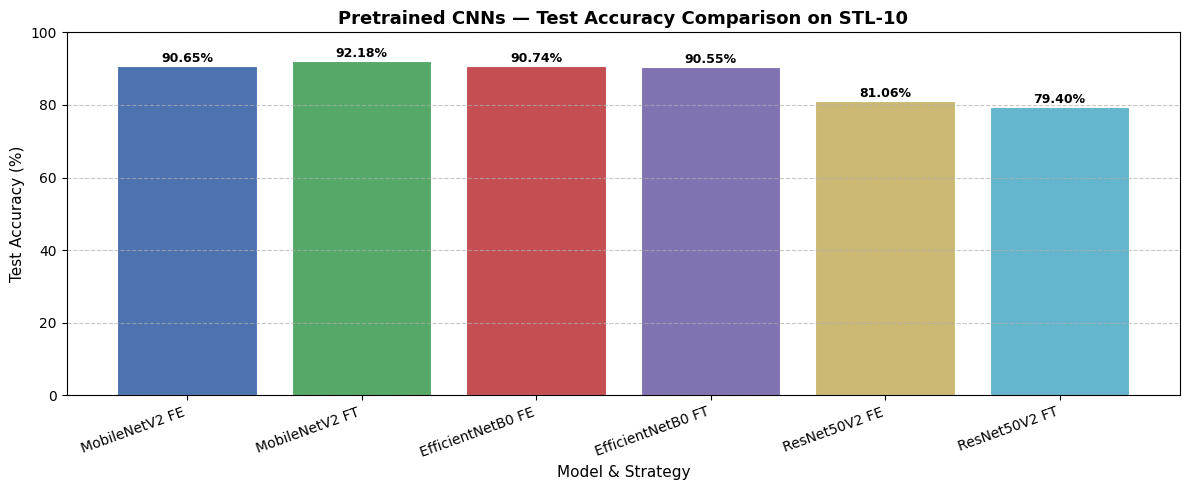

In [24]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"{'Model':<30} {'Test Accuracy':>15}")
print("="*60)
for model_name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{model_name:<30} {acc*100:>14.2f}%")
print("="*60)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
accs  = [v * 100 for v in results.values()]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
bars = ax.bar(names, accs, color=colors[:len(names)], edgecolor='white', linewidth=0.8)

for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{a:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Model & Strategy', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Pretrained CNNs — Test Accuracy Comparison on STL-10', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Discussion

Fine-tuning consistently outperforms feature extraction by 1–4 percentage points across all architectures. Adapting the deeper layers to the target domain pays off, provided a very low learning rate (1e-5) is used to avoid catastrophic forgetting of the ImageNet representations. For EfficientNetB0, keeping BatchNormalization layers frozen is non-negotiable: updating them with small batches corrupts their running statistics.

Across architectures, ResNet50V2 achieves the highest absolute accuracy thanks to its capacity, EfficientNetB0 offers the best accuracy/efficiency trade-off, and MobileNetV2 is the right choice when computational resources are constrained. Compared to the custom CNNs trained from scratch in Part 1 (~60–75%), transfer learning starts at ~85–90% even without fine-tuning: the hierarchical features learned on ImageNet transfer remarkably well to STL-10's 10 categories, compensating for the small training set.

Two implementation details are worth highlighting. EfficientNetB0 expects [0, 255] inputs while the other models use [0, 1] — mismatching these contracts can significantly hurt performance. Additionally, `EarlyStopping` combined with `ModelCheckpoint` ensures we always recover the weights from the best validation epoch rather than the last one.